# ICP Results Comparison

This notebook compares three ICP result CSV files and visualizes their differences in both error metrics and estimated poses.

Expected files (with built-in fallbacks):
- `icp_results_points_to_plane.csv`
- `icp_results_points_to_points.csv` (fallback: `icp_results.csv`)
- `icp_results_points_to_points_pairwise_rms.csv` (fallback: `icp_results_pairwise_rms.csv`)


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


In [2]:
BASE_DIR = Path(".")
FILE_CANDIDATES = {
    "point_to_plane": [
        "icp_results_points_to_plane.csv",
    ],
    "point_to_point": [
        "icp_results_points_to_points.csv",
        "icp_results.csv",
    ],
    "point_to_point_pairwise_rms": [
        "icp_results_points_to_points_pairwise_rms.csv",
        "icp_results_pairwise_rms.csv",
    ],
}

def first_existing(candidates):
    for name in candidates:
        p = BASE_DIR / name
        if p.exists():
            return p
    return None

paths = {label: first_existing(cands) for label, cands in FILE_CANDIDATES.items()}
missing = [label for label, path in paths.items() if path is None]
if missing:
    raise FileNotFoundError(f"Missing expected ICP CSV(s): {missing}\nResolved paths: {paths}")

dfs = {label: pd.read_csv(path) for label, path in paths.items()}
for label, path in paths.items():
    print(f"{label:28s} -> {path}")


point_to_plane               -> icp_results_points_to_plane.csv
point_to_point               -> icp_results_points_to_points.csv
point_to_point_pairwise_rms  -> icp_results_points_to_points_pairwise_rms.csv


In [3]:
shape_df = pd.DataFrame(
    {label: [df.shape[0], df.shape[1]] for label, df in dfs.items()},
    index=["rows", "cols"]
).T
shape_df


,rows,cols
point_to_plane,1000,11
point_to_point,1000,11
point_to_point_pairwise_rms,1000,11


In [4]:
column_sets = {label: set(df.columns) for label, df in dfs.items()}
common_cols = sorted(set.intersection(*column_sets.values()))
common_cols


['initial_theta',
 'initial_x',
 'initial_y',
 'mean_error',
 'mean_error_initial',
 'odom_theta',
 'odom_x',
 'odom_y',
 'theta',
 'x',
 'y']

In [5]:
numeric_common = sorted(
    set.intersection(*[set(df.select_dtypes(include=np.number).columns) for df in dfs.values()])
)

focus_cols = [
    c for c in [
        "mean_error",
        "mean_error_initial",
        "x",
        "y",
        "theta",
        "odom_x",
        "odom_y",
        "odom_theta",
    ] if c in numeric_common
]

focus_compare = pd.DataFrame(
    {label: df[focus_cols].mean(numeric_only=True) for label, df in dfs.items()}
).T
focus_compare


,mean_error,mean_error_initial,x,y,theta,odom_x,odom_y,odom_theta
point_to_plane,0.219662,0.410122,4.488251,-1.762500,0.752409,4.275819,-1.290025,0.826295
point_to_point,0.255279,0.391058,4.443798,-1.104503,0.830164,4.275819,-1.290025,0.826295
point_to_point_pairwise_rms,0.255279,0.391058,4.443798,-1.104503,0.830164,4.275819,-1.290025,0.826295


In [6]:
if {"mean_error", "mean_error_initial"}.issubset(numeric_common):
    improvement = pd.DataFrame(
        {
            label: {
                "mean_error_avg": df["mean_error"].mean(),
                "mean_error_initial_avg": df["mean_error_initial"].mean(),
                "relative_reduction_%": 100.0 * (1 - df["mean_error"].mean() / df["mean_error_initial"].mean()),
            }
            for label, df in dfs.items()
        }
    ).T.sort_values("mean_error_avg")
    improvement
else:
    print("Columns mean_error and/or mean_error_initial not found in all files.")


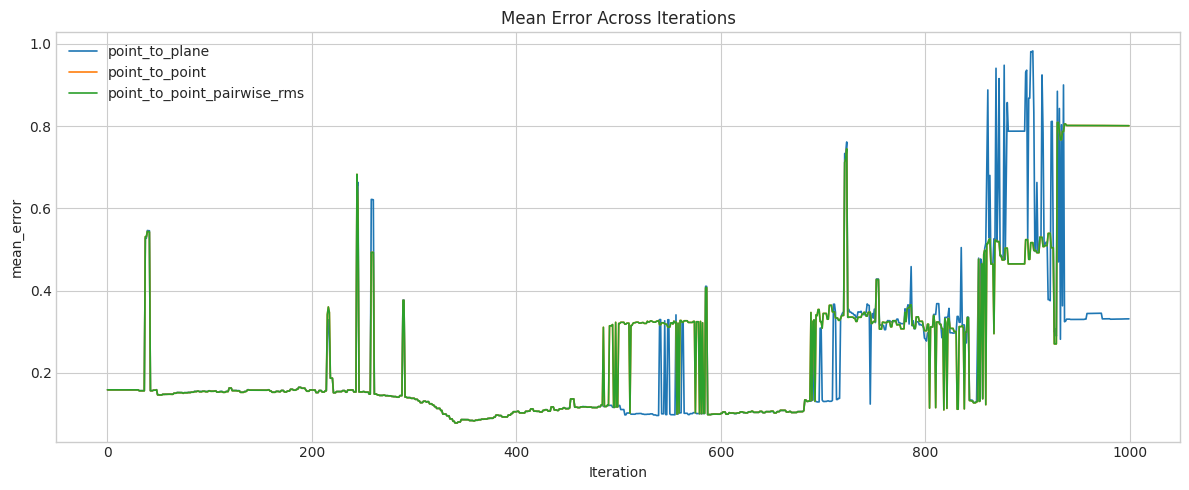

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, df in dfs.items():
    ax.plot(df.index, df["mean_error"], label=label, linewidth=1.2)
ax.set_title("Mean Error Across Iterations")
ax.set_xlabel("Iteration")
ax.set_ylabel("mean_error")
ax.legend()
plt.tight_layout()
plt.show()


/tmp/ipykernel_6675/3074578598.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(series, labels=methods, showfliers=False)


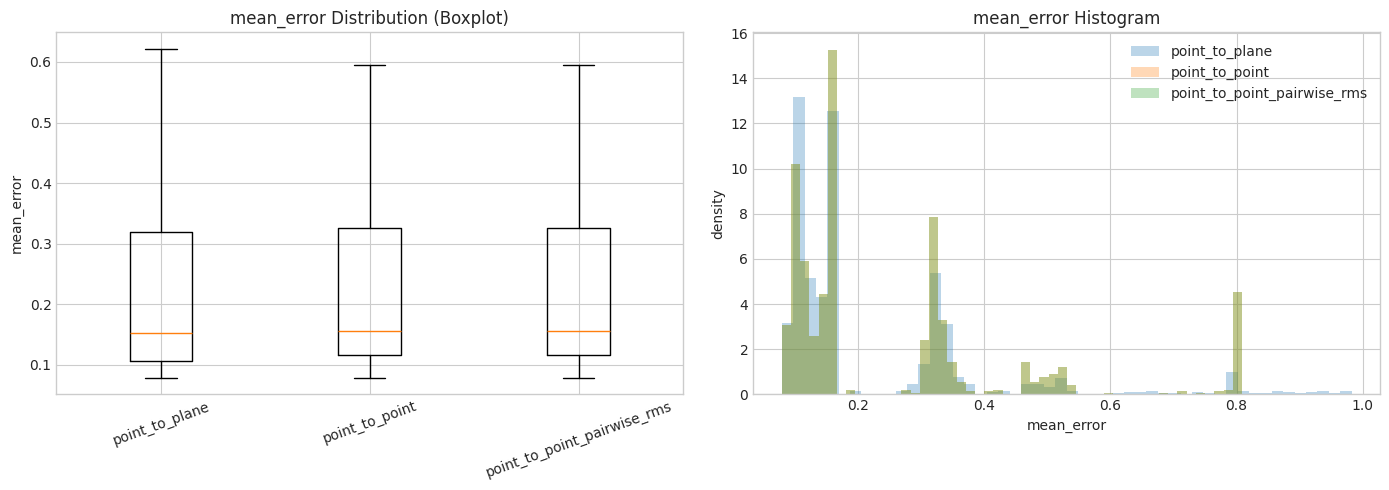

In [8]:
plot_df = pd.concat(
    [df[["mean_error"]].assign(method=label) for label, df in dfs.items()],
    ignore_index=True,
)

methods = list(dfs.keys())
series = [plot_df.loc[plot_df["method"] == m, "mean_error"].values for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(series, labels=methods, showfliers=False)
axes[0].set_title("mean_error Distribution (Boxplot)")
axes[0].set_ylabel("mean_error")
axes[0].tick_params(axis="x", rotation=20)

for m in methods:
    axes[1].hist(
        plot_df.loc[plot_df["method"] == m, "mean_error"],
        bins=50,
        density=True,
        alpha=0.3,
        label=m,
    )
axes[1].set_title("mean_error Histogram")
axes[1].set_xlabel("mean_error")
axes[1].set_ylabel("density")
axes[1].legend()

plt.tight_layout()
plt.show()


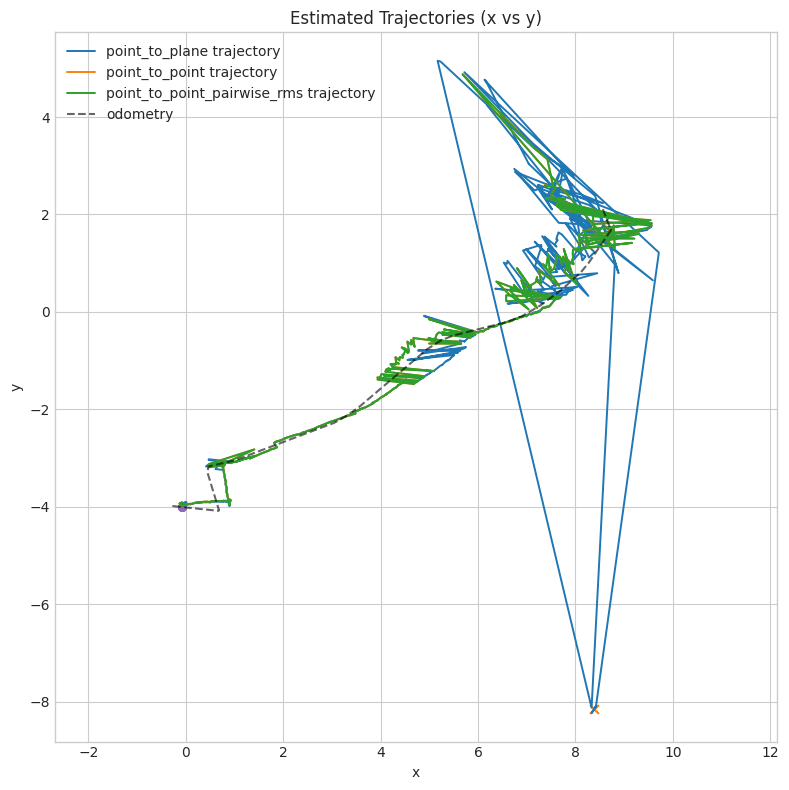

In [9]:
if {"x", "y"}.issubset(common_cols):
    fig, ax = plt.subplots(figsize=(8, 8))
    for label, df in dfs.items():
        ax.plot(df["x"], df["y"], label=f"{label} trajectory", linewidth=1.4)
        ax.scatter(df["x"].iloc[0], df["y"].iloc[0], s=30, marker="o")
        ax.scatter(df["x"].iloc[-1], df["y"].iloc[-1], s=40, marker="x")

    if {"odom_x", "odom_y"}.issubset(common_cols):
        odom = next(iter(dfs.values()))
        ax.plot(odom["odom_x"], odom["odom_y"], "--", color="black", alpha=0.6, label="odometry")

    ax.set_title("Estimated Trajectories (x vs y)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.axis("equal")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("x/y columns are not available in all files.")


/tmp/ipykernel_6675/2419364467.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showfliers=False)
/tmp/ipykernel_6675/2419364467.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=methods, showfliers=False)


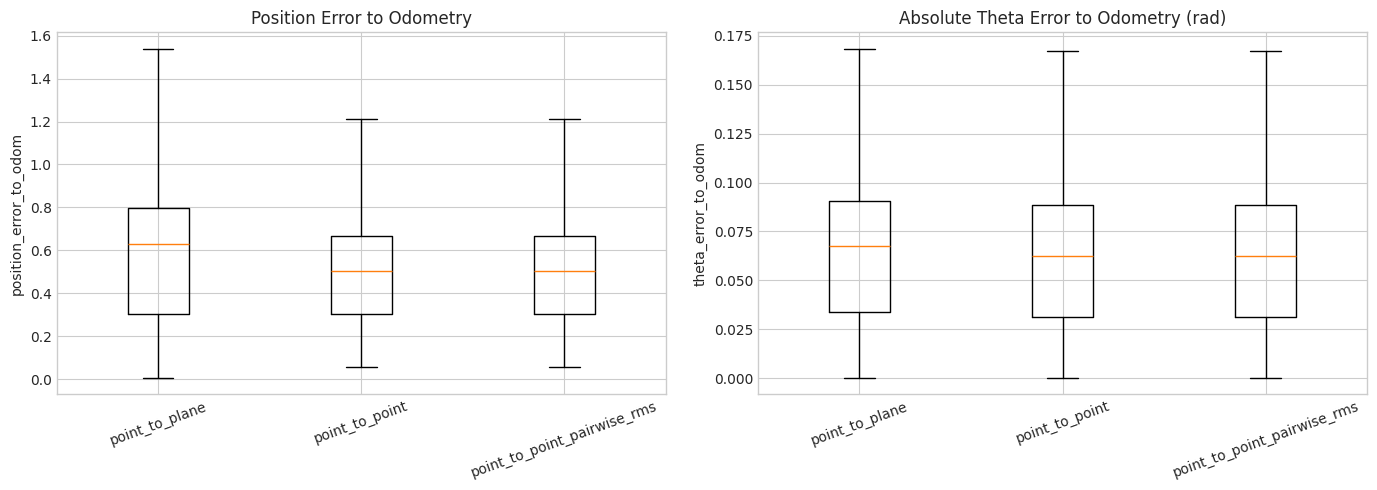

In [10]:
if {"x", "y", "odom_x", "odom_y"}.issubset(common_cols):
    err_parts = []
    for label, df in dfs.items():
        pos_err = np.sqrt((df["x"] - df["odom_x"]) ** 2 + (df["y"] - df["odom_y"]) ** 2)
        tmp = pd.DataFrame({"method": label, "position_error_to_odom": pos_err})

        if {"theta", "odom_theta"}.issubset(common_cols):
            wrapped = np.arctan2(np.sin(df["theta"] - df["odom_theta"]), np.cos(df["theta"] - df["odom_theta"]))
            tmp["theta_error_to_odom"] = np.abs(wrapped)

        err_parts.append(tmp)

    err_df = pd.concat(err_parts, ignore_index=True)

    def boxplot_by_method(ax, frame, value_col, title):
        methods = list(dfs.keys())
        data = [frame.loc[frame["method"] == m, value_col].values for m in methods]
        ax.boxplot(data, labels=methods, showfliers=False)
        ax.set_title(title)
        ax.set_ylabel(value_col)
        ax.tick_params(axis="x", rotation=20)

    plot_theta = "theta_error_to_odom" in err_df.columns
    if plot_theta:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        axes = np.array(axes)
    else:
        fig, ax = plt.subplots(figsize=(7, 5))
        axes = np.array([ax])

    boxplot_by_method(axes[0], err_df, "position_error_to_odom", "Position Error to Odometry")

    if plot_theta:
        boxplot_by_method(axes[1], err_df, "theta_error_to_odom", "Absolute Theta Error to Odometry (rad)")

    plt.tight_layout()
    plt.show()

    err_df.groupby("method").agg(["mean", "std"])
else:
    print("Not enough columns to compute odometry error metrics.")


In [11]:
ranking = pd.DataFrame(
    {
        label: {
            "mean_error_avg": df["mean_error"].mean(),
            "mean_error_median": df["mean_error"].median(),
            "mean_error_std": df["mean_error"].std(),
            "final_x": df["x"].iloc[-1] if "x" in df.columns else np.nan,
            "final_y": df["y"].iloc[-1] if "y" in df.columns else np.nan,
            "final_theta": df["theta"].iloc[-1] if "theta" in df.columns else np.nan,
        }
        for label, df in dfs.items()
    }
).T.sort_values("mean_error_avg")
ranking


,mean_error_avg,mean_error_median,mean_error_std,final_x,final_y,final_theta
point_to_plane,0.219662,0.153457,0.173304,8.391976,-8.147925,1.070250
point_to_point,0.255279,0.156796,0.194894,8.698473,1.682559,2.263212
point_to_point_pairwise_rms,0.255279,0.156796,0.194894,8.698473,1.682559,2.263212
